# Zebrafish growth across developmental stages

Evaluate the growth network on the five observed zebrafish populations and
draw the spatial maps in Supplementary Fig. S32. The model returns a growth
value for every cell. No trajectory simulation is needed for this figure.

## Load the data

After [installation](../../installation.md), extract `zebrafish_model.zip`
and `zebrafish_analysis_data.zip` from the [data page](../../data_checkpoints.md)
into the same project directory. Set `PROJECT_DIR` below to that directory.
To fit a new model, follow [Train a model](../../training.md).

In [1]:
from pathlib import Path
import os
import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
import CytoBridge as cb
from CytoBridge.workflow import load_workflow_config

PROJECT_DIR = Path(os.environ.get("CYTOBRIDGE_PROJECT_DIR", ".")).resolve()
DATA_DIR = PROJECT_DIR / "data" / "zebrafish"
OUTPUT_DIR = PROJECT_DIR / "outputs" / "zebrafish_growth"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
DEVICE = "cuda"
config, _ = load_workflow_config(DATA_DIR / "workflow.json")
fields = config["dataset"]
plt.rcParams.update({
    "font.family": "Arial", "font.size": 9, "text.color": "black",
    "axes.labelcolor": "black", "xtick.color": "black", "ytick.color": "black",
    "pdf.fonttype": 42, "svg.fonttype": "none",
})

The aligned file contains the spatial coordinates and PCA scores used for
training. `model_state_adata` copies these features into `X`, with the two
spatial coordinates followed by the 50 expression features. Backed reading
avoids loading the full gene-expression matrix.

In [2]:
aligned = sc.read_h5ad(DATA_DIR / "aligned.h5ad", backed="r")
try:
    states = cb.tl.model_state_adata(
        aligned, time_key=fields["time_key"], latent_key=fields["obsm_key"],
        spatial_key=fields["spatial_key"],
    )
finally:
    aligned.file.close()
times = [0.0, 1.0, 2.0, 3.0, 4.0]
slices = {str(t): states[states.obs["time_point_processed"] == t].copy() for t in times}
pd.Series({t: population.n_obs for t, population in slices.items()}, name="Observed cells")

0.0     563
1.0    1036
2.0    2081
3.0    3048
4.0    5271
Name: Observed cells, dtype: int64

## Load the trained model

The model folder contains the configuration and trained networks. The edge
predictor is loaded with the model, although this calculation evaluates only
the growth network.

In [3]:
loaded = cb.tl.load_dynamical_model_from_dir(
    DATA_DIR / "model", dim=states.n_vars, device=DEVICE,
    edge_predictor_path=DATA_DIR / "edge_classifier" / "zebrafish_edge_model.pt",
)

## Calculate per-cell growth

`evaluate_growth_by_timepoint` evaluates the network using each cell's model
state and time. It returns the values in a table and also stores them in
`slices[t].obs['growth_rate']` for plotting. Keep this table if you want to
change the display without evaluating the model again.

In [4]:
growth = cb.tl.evaluate_growth_by_timepoint(
    slices, loaded.model, time_points=times,
    annotation_key=fields["annotation_key"], device=DEVICE,
)
growth.to_csv(OUTPUT_DIR / "growth_per_cell.csv", index=False)
growth.head()

,time,time_key,cell_index,x,y,growth,celltype
0,0.0,0.0,0,-0.966541,4.046007,0.194854,EVL
1,0.0,0.0,1,-0.109008,4.021175,0.189216,EVL
2,0.0,0.0,2,-0.137154,3.970739,0.307365,EVL
3,0.0,0.0,3,0.136774,3.870492,0.442672,EVL
4,0.0,0.0,4,0.041672,3.723786,0.421275,"Presumptive Mesoderm, Presumptive Ectoderm"


## Draw the spatial maps — S32

Within each stage, the 5th and 95th percentiles set the colour limits. Thus,
the maps show relative spatial variation within a stage, not absolute
differences between stages. Values outside that range use the end colours.
The CSV above keeps the original growth values.

In [5]:
colour_limits = growth.groupby("time")["growth"].quantile([0.05, 0.95]).unstack()
colour_limits.columns = ["5th percentile", "95th percentile"]
colour_limits.to_csv(OUTPUT_DIR / "growth_colour_limits.csv")
colour_limits

,5th percentile,95th percentile
time,,
0.0,0.213864,0.789930
1.0,0.464174,1.094305
2.0,0.340944,0.928520
3.0,0.273028,0.646693
4.0,0.502342,1.051635


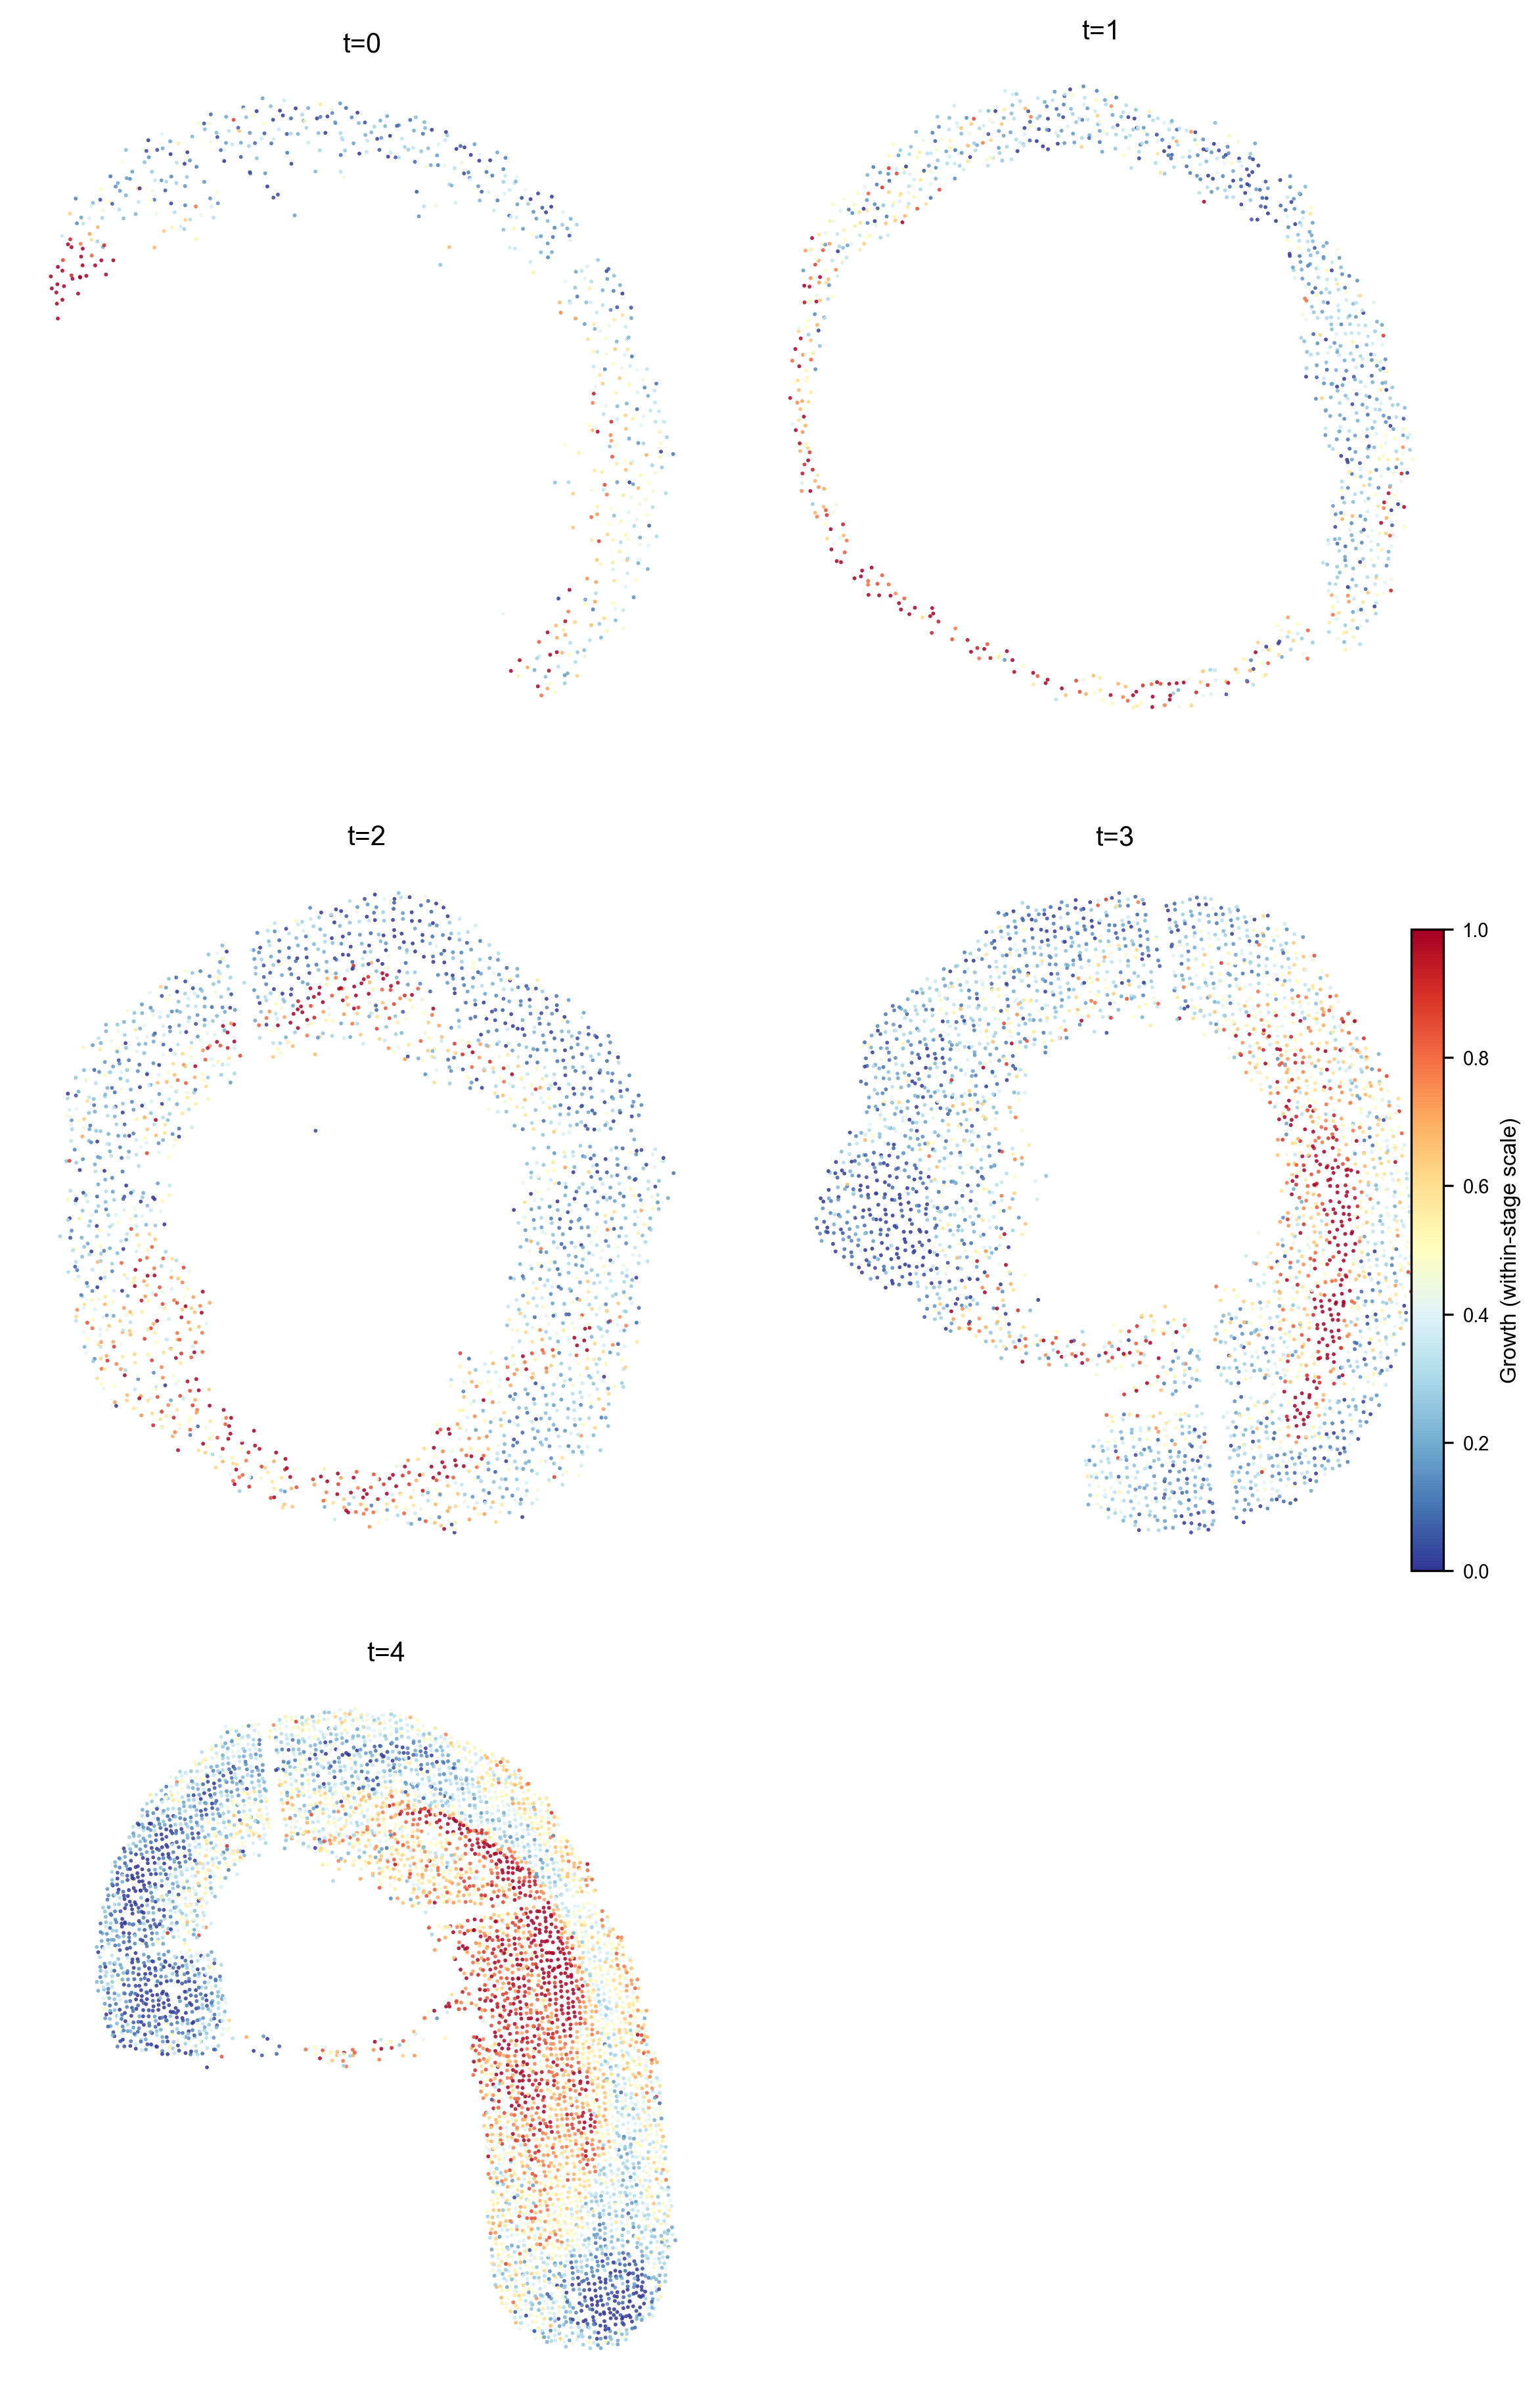

In [6]:
growth_map = cb.pl.plot_growth_timepoint_grid(
    slices, time_points=times,
    out_path=str(OUTPUT_DIR / "zebrafish_growth_S32.pdf"),
    n_cols=2, cmap="RdYlBu_r", point_size=2.0,
    lower_quantile=0.05, upper_quantile=0.95,
    scale_mode="per_time_0_1", shared_colorbar=True,
    colorbar_label="Growth (within-stage scale)", show=True,
)

## Other zebrafish analyses

The [S31–S38 notebooks](../paper_figures/zebrafish_si_s31_s38.ipynb)
plot the paper's saved numerical results for generated states, virtual cell
removal, gene dynamics, and sensitivity analyses. They start from their own
simulation results, not from the growth table produced here.
[S39](../paper_figures/zebrafish_attention.ipynb)
compares interaction attention, and [S40](../paper_figures/zebrafish_decomposition_stability.md)
compares training seeds and model settings.